# 1. Đọc dữ liệu (1 điểm)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv('black_friday.csv')

# Hiển thị 5 dòng đầu tiên
print(df.head())

   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
0                          2               0                   3   
1                          2               0                   1   
2                          2               0                  12   
3                          2               0                  12   
4                         4+               0                   8   

   Product_Category_2  Product_Category_3  Purchase  
0                 NaN                 NaN      8370  
1                 6.0                14.0     15200  
2                 NaN                 NaN   

# 2. Thông tin dữ liệu (1 điểm)

In [3]:
# Kiểm tra số dòng và số cột
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

# Kiểm tra số lượng giá trị bị thiếu trong từng cột
print("\nGiá trị bị thiếu:")
print(df.isnull().sum())

Số dòng: 550068, Số cột: 12

Giá trị bị thiếu:
User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64


Nhận xét:
- Dữ liệu có hàng nghìn giao dịch
- Có giá trị thiếu ở Product_Category_2 và Product_Category_3
- Cột Purchase chứa thông tin chi tiêu quan trọng

# 3. Phân loại thuộc tính (1 điểm)

In [4]:
# Code
print("Các cột số:")
print(df.select_dtypes(include=['number']).columns.tolist())
print("\nCác cột phân loại:")
print(df.select_dtypes(include=['object']).columns.tolist())

Các cột số:
['User_ID', 'Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']

Các cột phân loại:
['Product_ID', 'Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']


- Các thuộc tính định tính (Categorical):
  User_ID, Product_ID, Gender, Age, Occupation, City_Category, Stay_In_Current_City_Years, Marital_Status

- Các thuộc tính định lượng (Numerical):
  Product_Category_1, Product_Category_2, Product_Category_3, Purchase

# 4. Sản phẩm phổ biến (1 điểm)

In [5]:
# Số lượng loại sản phẩm khác nhau
print(f"Số sản phẩm khác nhau: {df['Product_ID'].nunique()}")

# Sản phẩm được mua nhiều nhất
top_product = df['Product_ID'].value_counts().head(1)
print(f"\nSản phẩm được mua nhiều nhất: {top_product.index[0]} ({top_product.iloc[0]} lần)")

Số sản phẩm khác nhau: 3631

Sản phẩm được mua nhiều nhất: P00265242 (1880 lần)


Nhận xét:
- Có nhiều sản phẩm khác nhau
- Một số sản phẩm có tần suất mua cao

# 5. Tỷ lệ nam và nữ (1 điểm)

Gender
M    414259
F    135809
Name: count, dtype: int64

Tỷ lệ %: Gender
M    75.3
F    24.7
Name: count, dtype: float64


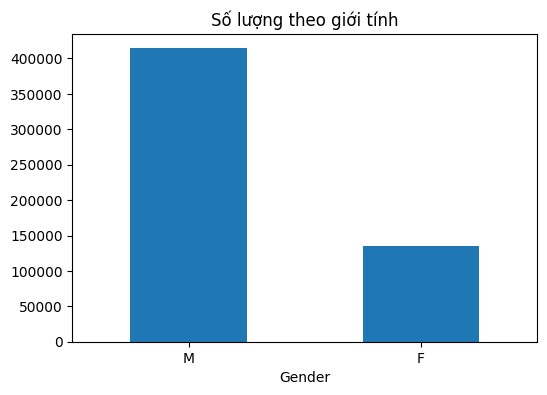

In [6]:
# Đếm số lượng nam và nữ
gender_counts = df['Gender'].value_counts()
print(gender_counts)
print(f"\nTỷ lệ %: {(gender_counts/len(df)*100).round(1)}")

# Trực quan hóa (biểu đồ histogram)
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar')
plt.title('Số lượng theo giới tính')
plt.xticks(rotation=0)
plt.show()

# 6. Nhóm tuổi có mức chi tiêu trung bình cao nhất (1 điểm)

In [7]:
# Tính mức chi tiêu trung bình theo nhóm tuổi
avg_spending = df.groupby('Age')['Purchase'].mean().sort_values(ascending=False)
print(avg_spending)

# Hiển thị nhóm tuổi có mức chi tiêu cao nhất
print(f"\nNhóm tuổi chi tiêu cao nhất: {avg_spending.index[0]} ({avg_spending.iloc[0]:,.0f})")

Age
51-55    9534.808031
55+      9336.280459
36-45    9331.350695
26-35    9252.690633
46-50    9208.625697
18-25    9169.663606
0-17     8933.464640
Name: Purchase, dtype: float64

Nhóm tuổi chi tiêu cao nhất: 51-55 (9,535)


# 7. Thống kê mức chi tiêu

In [8]:
# Tính các đại lượng thống kê
print(df['Purchase'].describe())

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64


Nhận xét:
- Mức chi tiêu có phân bố rộng
- Có chênh lệch lớn giữa min và max

# 8. Trực quan hóa phân bố chi tiêu

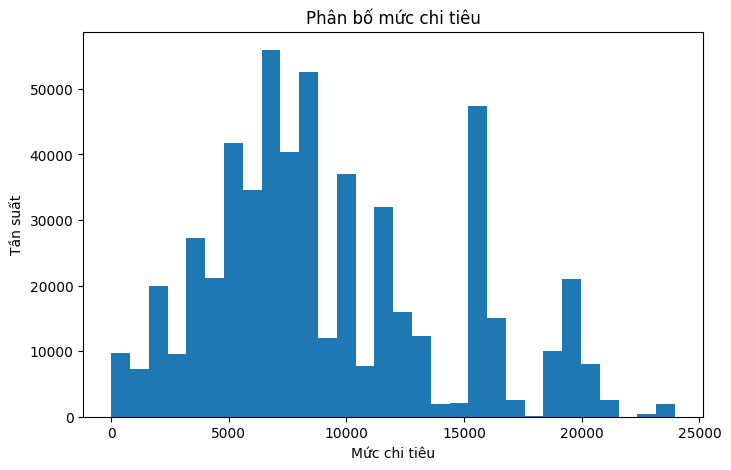

In [9]:
# Vẽ đồ thị Histogram hoặc Line hoặc hỗn hợp.
plt.figure(figsize=(8, 5))
plt.hist(df['Purchase'], bins=30)
plt.title('Phân bố mức chi tiêu')
plt.xlabel('Mức chi tiêu')
plt.ylabel('Tần suất')
plt.show()

Nhận xét:
- Phân bố lệch phải
- Có outliers ở mức chi tiêu cao

# 9. Biểu đồ hộp so sánh mức chi tiêu theo nhóm tuổi và giới tính (1 điểm)

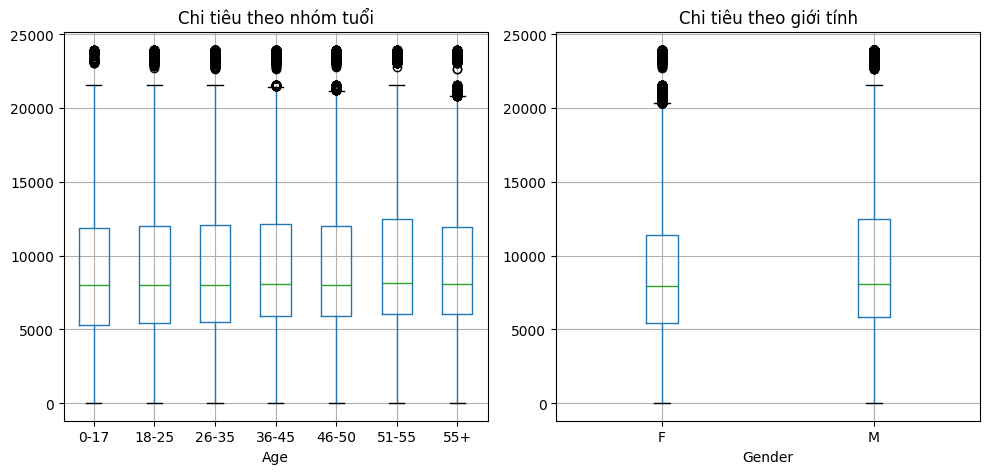

In [13]:
# Biểu đồ hộp (box-plot)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df.boxplot(column='Purchase', by='Age', ax=plt.gca())
plt.title('Chi tiêu theo nhóm tuổi')
plt.suptitle('')

plt.subplot(1, 2, 2)
df.boxplot(column='Purchase', by='Gender', ax=plt.gca())
plt.title('Chi tiêu theo giới tính')
plt.suptitle('')

plt.tight_layout()
plt.show()

Nhận xét:
- Nam giới chi tiêu nhiều hơn nữ giới
- Các nhóm tuổi có mức chi tiêu khác nhau

# 10. Biểu đồ tròn thể hiện tỷ lệ tổng chi tiêu của từng nhóm tuổi

Age
0-17      134913183
18-25     913848675
26-35    2031770578
36-45    1026569884
46-50     420843403
51-55     367099644
55+       200767375
Name: Purchase, dtype: int64


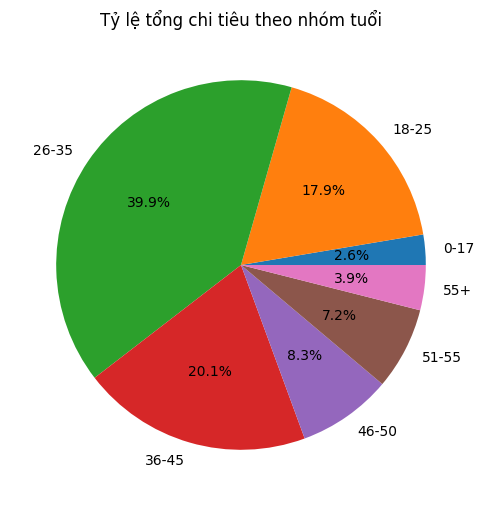

In [11]:
# Biểu đồ tròn
total_by_age = df.groupby('Age')['Purchase'].sum()
print(total_by_age)

plt.figure(figsize=(6, 6))
plt.pie(total_by_age.values, labels=total_by_age.index, autopct='%1.1f%%')
plt.title('Tỷ lệ tổng chi tiêu theo nhóm tuổi')
plt.show()